# PX4 Phase 1 Rate Dynamics PINN Training v7 Aux Accel

v7 keeps the stable v6 direct-delta baseline and adds auxiliary acceleration supervision from the v13 dataset.

Model contract remains small for future MPC use:

```text
x_t, u_t, prev_u_t, du_t, dt_s -> dx_t
```

Training additionally predicts auxiliary targets:

```text
aux_derived_accel_* and aux_derived_*_accel_rad_s2
```

Those auxiliary targets are used only during training to teach translational acceleration and angular acceleration consistency. Runtime MPC can ignore the auxiliary head.


In [1]:
# Colab setup
from pathlib import Path
import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)


Mounted at /content/drive
device: cuda
torch: 2.10.0+cu128


In [2]:
# Dataset path
# Set this manually if the processed v3 folder is in Google Drive.
DATASET_DIR = ''  # e.g. '/content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v3_imu_aux_20260506_210000'

# Otherwise search common local/Drive locations.
def find_latest_dataset_dir():
    import glob
    patterns = [
        '/content/drive/MyDrive/**/px4_phase1_rate_dynamics_dataset_v3_imu_aux_*',
        '/content/**/px4_phase1_rate_dynamics_dataset_v3_imu_aux_*',
        './px4_phase1_rate_dynamics_dataset_v3_imu_aux_*',
    ]
    matches = []
    for pat in patterns:
        matches.extend(glob.glob(pat, recursive=True))
    matches = sorted(set(matches))
    matches = [Path(m) for m in matches if (Path(m) / 'train.csv').exists()]
    if not matches:
        raise FileNotFoundError('No v3 processed dataset found. Set DATASET_DIR manually.')
    return matches[-1]

DATASET_PATH = Path(DATASET_DIR) if DATASET_DIR else find_latest_dataset_dir()
print('DATASET_PATH:', DATASET_PATH)
print('files:', sorted([p.name for p in DATASET_PATH.iterdir()])[:20])


DATASET_PATH: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v3_imu_aux_20260508_173737
files: ['all_samples.csv', 'dataset_summary.csv', 'filter_report.csv', 'metadata.json', 'source_summary.csv', 'test.csv', 'train.csv', 'val.csv']


In [3]:
# Load processed CSVs and rebuild nominal validation split
base_train = pd.read_csv(DATASET_PATH / 'train.csv')
base_val = pd.read_csv(DATASET_PATH / 'val.csv')
base_test = pd.read_csv(DATASET_PATH / 'test.csv')
all_df = pd.read_csv(DATASET_PATH / 'all_samples.csv') if (DATASET_PATH / 'all_samples.csv').exists() else pd.concat([base_train, base_val, base_test], ignore_index=True)

metadata = {}
if (DATASET_PATH / 'metadata.json').exists():
    metadata = json.loads((DATASET_PATH / 'metadata.json').read_text())

state_cols = metadata.get('state_cols') or [c.removeprefix('dx_') for c in all_df.columns if c.startswith('dx_')]
action_cols = metadata.get('action_cols') or [c.removeprefix('u_') for c in all_df.columns if c.startswith('u_')]

feature_cols = (
    [f'x_{c}' for c in state_cols]
    + [f'u_{c}' for c in action_cols]
    + [f'prev_u_{c}' for c in action_cols]
    + [f'du_{c}' for c in action_cols]
    + ['dt_s']
)
target_cols = [f'dx_{c}' for c in state_cols]
next_cols = [f'x_next_{c}' for c in state_cols]

# Use derived auxiliary targets by default. Optional IMU columns are not used here
# unless they are nearly complete across all splits.
aux_candidates = [c for c in all_df.columns if c.startswith('aux_derived_')]
aux_cols = []
for c in aux_candidates:
    ok = all_df[c].notna().mean() >= 0.95
    ok = ok and base_train[c].notna().mean() >= 0.95 and base_val[c].notna().mean() >= 0.95
    if len(base_test) and c in base_test.columns:
        ok = ok and base_test[c].notna().mean() >= 0.90
    if ok:
        aux_cols.append(c)

missing = [c for c in feature_cols + target_cols + aux_cols if c not in all_df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')
if not aux_cols:
    raise ValueError('No usable aux_derived_* columns found. Rebuild with px4_dataset_builder_v3.')

# Remove rows with missing features/targets/aux after optional-column selection.
needed = feature_cols + target_cols + aux_cols
all_df = all_df[np.isfinite(all_df[needed].to_numpy(np.float32)).all(axis=1)].copy()

RESPLIT_FOR_NOMINAL_VALIDATION = True
TEST_SCENARIOS = ['N11_mixed_sequence']
VAL_FRACTION = 0.15

if RESPLIT_FOR_NOMINAL_VALIDATION:
    rng = np.random.default_rng(SEED)
    test_mask = all_df['scenario'].isin(TEST_SCENARIOS) if 'scenario' in all_df.columns else pd.Series(False, index=all_df.index)
    test_df = all_df[test_mask].copy()
    pool_df = all_df[~test_mask].copy()
    val_indices = []
    group_cols = [c for c in ['source_run', 'scenario'] if c in pool_df.columns]
    if group_cols:
        for _, group in pool_df.groupby(group_cols, sort=False):
            n_val = max(1, int(round(len(group) * VAL_FRACTION))) if len(group) >= 20 else 0
            if n_val:
                val_indices.extend(rng.choice(group.index.to_numpy(), size=n_val, replace=False).tolist())
    else:
        n_val = int(round(len(pool_df) * VAL_FRACTION))
        val_indices = rng.choice(pool_df.index.to_numpy(), size=n_val, replace=False).tolist()
    val_df = pool_df.loc[sorted(val_indices)].copy()
    train_df = pool_df.drop(index=val_df.index).copy()
else:
    train_df, val_df, test_df = base_train, base_val, base_test

print('train/val/test rows:', len(train_df), len(val_df), len(test_df))
print('state_cols:', state_cols)
print('action_cols:', action_cols)
print('aux_cols:', aux_cols)
print('n_features:', len(feature_cols), 'n_targets:', len(target_cols), 'n_aux:', len(aux_cols))

display(pd.DataFrame({'split': ['train', 'val', 'test'], 'rows': [len(train_df), len(val_df), len(test_df)]}))
if 'scenario' in train_df.columns:
    split_view = pd.concat([train_df.assign(split='train'), val_df.assign(split='val'), test_df.assign(split='test')])
    display(split_view.groupby(['split', 'scenario']).size().to_frame('rows').reset_index())


train/val/test rows: 13440 2377 1445
state_cols: ['relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
action_cols: ['ref_roll_rate_rad_s', 'ref_pitch_rate_rad_s', 'ref_yaw_rate_rad_s', 'ref_thrust']
aux_cols: ['aux_derived_accel_north_m_s2', 'aux_derived_accel_east_m_s2', 'aux_derived_accel_down_m_s2', 'aux_derived_roll_accel_rad_s2', 'aux_derived_pitch_accel_rad_s2', 'aux_derived_yaw_accel_rad_s2']
n_features: 23 n_targets: 10 n_aux: 6


,split,rows
0,train,13440
1,val,2377
2,test,1445


,split,scenario,rows
0,test,N11_mixed_sequence,1445
1,train,N00_hover_hold_0p5192,1016
2,train,N01_pitch_rate_doublet_5dps,1186
3,train,N02_pitch_rate_doublet_10dps,1165
4,train,N03_roll_rate_doublet_5dps,1120
5,train,N04_roll_rate_doublet_10dps,1186
6,train,N05_yaw_rate_doublet_10dps,1186
7,train,N06_yaw_rate_doublet_20dps,1777
8,train,N07_thrust_step_pm010,1186
9,train,N08_thrust_step_pm020,1186


,column,split,mean,std,min,max
0,dx_relative_altitude_m,train,-1.477314e-02,0.050079,-1.940001,0.163000
1,dx_vel_north_m_s,train,-1.019345e-04,0.006281,-0.100000,0.140000
2,dx_vel_east_m_s,train,-1.934521e-05,0.006581,-0.170000,0.150000
3,dx_vel_down_m_s,train,8.139881e-04,0.004850,-0.110000,0.080000
4,dx_roll_deg,train,9.687067e-05,0.039312,-0.632356,0.624648
5,dx_pitch_deg,train,-2.729873e-06,0.035268,-0.651682,0.644066
6,dx_yaw_deg,train,-3.264183e-03,0.088913,-1.361549,1.199600
7,dx_roll_rate_rad_s,train,2.214428e-05,0.003564,-0.123753,0.096010
8,dx_pitch_rate_rad_s,train,-3.283207e-06,0.003320,-0.096853,0.117028
9,dx_yaw_rate_rad_s,train,6.661613e-06,0.002943,-0.042475,0.041177


,column,split,mean,std,min,max
0,aux_derived_accel_north_m_s2,train,-0.002234,0.127145,-2.037633,2.919735
1,aux_derived_accel_east_m_s2,train,0.000315,0.130249,-3.595831,3.059764
2,aux_derived_accel_down_m_s2,train,0.015808,0.095263,-2.188585,1.466013
3,aux_derived_roll_accel_rad_s2,train,0.000238,0.074436,-2.543079,2.194956
4,aux_derived_pitch_accel_rad_s2,train,0.000365,0.065022,-2.015535,2.167558
5,aux_derived_yaw_accel_rad_s2,train,0.000140,0.059253,-0.788380,1.104527
6,aux_derived_accel_north_m_s2,val,-0.002472,0.114438,-1.132810,0.954036
7,aux_derived_accel_east_m_s2,val,-0.000981,0.140964,-2.534155,1.335650
8,aux_derived_accel_down_m_s2,val,0.019608,0.100173,-0.706651,1.879275
9,aux_derived_roll_accel_rad_s2,val,-0.001360,0.066186,-1.427213,1.166172


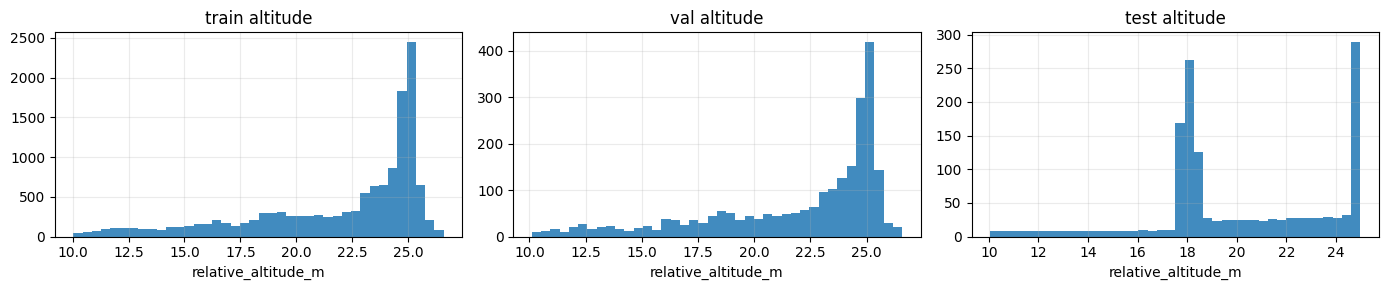

In [4]:
# Basic data sanity
def describe_cols(df, name, cols):
    desc = df[cols].agg(['mean', 'std', 'min', 'max']).T
    desc.insert(0, 'split', name)
    return desc.reset_index().rename(columns={'index': 'column'})

display(pd.concat([describe_cols(train_df, 'train', target_cols), describe_cols(val_df, 'val', target_cols), describe_cols(test_df, 'test', target_cols)], ignore_index=True))
display(pd.concat([describe_cols(train_df, 'train', aux_cols), describe_cols(val_df, 'val', aux_cols), describe_cols(test_df, 'test', aux_cols)], ignore_index=True))

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, df, title in zip(axes, [train_df, val_df, test_df], ['train', 'val', 'test']):
    ax.hist(df['x_relative_altitude_m'], bins=40, alpha=0.85)
    ax.set_title(f'{title} altitude')
    ax.set_xlabel('relative_altitude_m')
    ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [5]:
# Scaling and dataloaders
class StandardScaler:
    def __init__(self, mean, std):
        self.mean = np.asarray(mean, dtype=np.float32)
        self.std = np.asarray(std, dtype=np.float32)
        self.std = np.where(self.std < 1e-8, 1.0, self.std)

    @classmethod
    def fit(cls, arr):
        return cls(np.nanmean(arr, axis=0), np.nanstd(arr, axis=0))

    def transform(self, arr):
        return (np.asarray(arr, dtype=np.float32) - self.mean) / self.std

    def inverse_transform(self, arr):
        return np.asarray(arr, dtype=np.float32) * self.std + self.mean

    def to_dict(self, columns):
        return {'columns': list(columns), 'mean': self.mean.tolist(), 'std': self.std.tolist()}

X_train_raw = train_df[feature_cols].to_numpy(np.float32)
Y_train_raw = train_df[target_cols].to_numpy(np.float32)
A_train_raw = train_df[aux_cols].to_numpy(np.float32)
X_val_raw = val_df[feature_cols].to_numpy(np.float32)
Y_val_raw = val_df[target_cols].to_numpy(np.float32)
A_val_raw = val_df[aux_cols].to_numpy(np.float32)
X_test_raw = test_df[feature_cols].to_numpy(np.float32)
Y_test_raw = test_df[target_cols].to_numpy(np.float32)
A_test_raw = test_df[aux_cols].to_numpy(np.float32)

x_scaler = StandardScaler.fit(X_train_raw)
y_scaler = StandardScaler.fit(Y_train_raw)
a_scaler = StandardScaler.fit(A_train_raw)

X_train = x_scaler.transform(X_train_raw)
Y_train = y_scaler.transform(Y_train_raw)
A_train = a_scaler.transform(A_train_raw)
X_val = x_scaler.transform(X_val_raw)
Y_val = y_scaler.transform(Y_val_raw)
A_val = a_scaler.transform(A_val_raw)
X_test = x_scaler.transform(X_test_raw)
Y_test = y_scaler.transform(Y_test_raw)
A_test = a_scaler.transform(A_test_raw)

BATCH_SIZE = 1024
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(Y_train), torch.tensor(A_train)), batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(Y_val), torch.tensor(A_val)), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

x_mean_t = torch.tensor(x_scaler.mean, dtype=torch.float32, device=device)
x_std_t = torch.tensor(x_scaler.std, dtype=torch.float32, device=device)
y_mean_t = torch.tensor(y_scaler.mean, dtype=torch.float32, device=device)
y_std_t = torch.tensor(y_scaler.std, dtype=torch.float32, device=device)
a_mean_t = torch.tensor(a_scaler.mean, dtype=torch.float32, device=device)
a_std_t = torch.tensor(a_scaler.std, dtype=torch.float32, device=device)
feature_index = {c: i for i, c in enumerate(feature_cols)}
target_index = {c: i for i, c in enumerate(target_cols)}
aux_index = {c: i for i, c in enumerate(aux_cols)}
print('batches:', len(train_loader), len(val_loader))


batches: 14 3


In [6]:
# Model: shared trunk with dx and auxiliary acceleration heads
class RateDynamicsAuxMLP(nn.Module):
    def __init__(self, n_in, n_out, n_aux, hidden=512, depth=5, dropout=0.02):
        super().__init__()
        layers = []
        last = n_in
        for _ in range(depth):
            layers += [nn.Linear(last, hidden), nn.SiLU(), nn.LayerNorm(hidden)]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            last = hidden
        self.trunk = nn.Sequential(*layers)
        self.dx_head = nn.Linear(last, n_out)
        self.aux_head = nn.Linear(last, n_aux)

    def forward(self, x):
        z = self.trunk(x)
        return self.dx_head(z), self.aux_head(z)

MODEL_CONFIG = dict(hidden=512, depth=5, dropout=0.02)
model = RateDynamicsAuxMLP(len(feature_cols), len(target_cols), len(aux_cols), **MODEL_CONFIG).to(device)
print(model)
print('parameters:', sum(p.numel() for p in model.parameters()))


RateDynamicsAuxMLP(
  (trunk): Sequential(
    (0): Linear(in_features=23, out_features=512, bias=True)
    (1): SiLU()
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.02, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): SiLU()
    (6): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): SiLU()
    (10): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (11): Dropout(p=0.02, inplace=False)
    (12): Linear(in_features=512, out_features=512, bias=True)
    (13): SiLU()
    (14): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (15): Dropout(p=0.02, inplace=False)
    (16): Linear(in_features=512, out_features=512, bias=True)
    (17): SiLU()
    (18): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (19): Dropout(p=0.02, inplace=False)
  )
  (dx_head): Linear(in_features=512, ou

epoch 0001 train=0.7042 val=0.2540 data=0.1287 aux=0.2125 aux_cons=0.6388 alt=0.0101 euler=0.0038 best=0.2540@1
epoch 0025 train=0.1610 val=0.1487 data=0.0804 aux=0.1295 aux_cons=0.3288 alt=0.0017 euler=0.0006 best=0.1474@22
epoch 0050 train=0.1544 val=0.1445 data=0.0790 aux=0.1244 aux_cons=0.3162 alt=0.0016 euler=0.0005 best=0.1429@47
epoch 0075 train=0.1478 val=0.1425 data=0.0775 aux=0.1231 aux_cons=0.3136 alt=0.0017 euler=0.0006 best=0.1415@68
epoch 0100 train=0.1480 val=0.1416 data=0.0766 aux=0.1228 aux_cons=0.3143 alt=0.0019 euler=0.0005 best=0.1402@95
epoch 0125 train=0.1439 val=0.1404 data=0.0766 aux=0.1213 aux_cons=0.3065 alt=0.0017 euler=0.0006 best=0.1395@121
epoch 0150 train=0.1415 val=0.1392 data=0.0760 aux=0.1207 aux_cons=0.3031 alt=0.0017 euler=0.0005 best=0.1391@129
epoch 0175 train=0.1412 val=0.1408 data=0.0764 aux=0.1220 aux_cons=0.3107 alt=0.0017 euler=0.0006 best=0.1391@129
epoch 0200 train=0.1395 val=0.1406 data=0.0764 aux=0.1214 aux_cons=0.3095 alt=0.0017 euler=0.0

,epoch,train_loss,train_data,train_aux,train_aux_cons,train_alt,train_euler,val_loss,val_data,val_aux,val_aux_cons,val_alt,val_euler,lr
254,255,0.137653,0.080520,0.107367,0.276268,0.001901,0.000782,0.142585,0.077356,0.122965,0.315296,0.001857,0.000680,0.000834
255,256,0.137015,0.080106,0.106720,0.275595,0.001917,0.000755,0.140888,0.076230,0.121794,0.312819,0.001750,0.000666,0.000833
256,257,0.136675,0.079852,0.106612,0.275166,0.001837,0.000761,0.141234,0.076885,0.122672,0.308552,0.001869,0.000605,0.000832
257,258,0.138143,0.080578,0.108163,0.278357,0.001972,0.000756,0.142033,0.077298,0.122419,0.312425,0.001719,0.000597,0.000831
258,259,0.137730,0.080356,0.107608,0.277820,0.001939,0.000755,0.142091,0.077437,0.123177,0.310310,0.001723,0.000638,0.000829


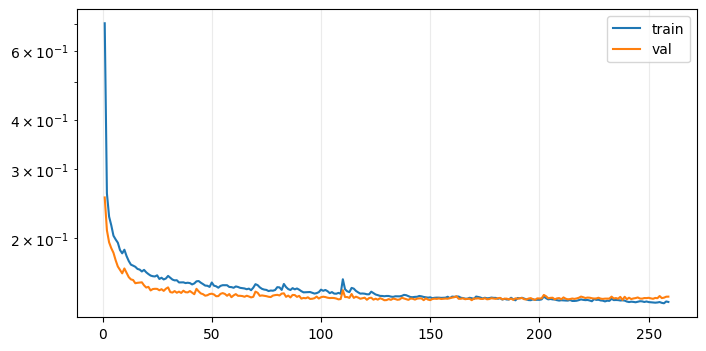

In [7]:
# Training with Euler physics and auxiliary acceleration consistency
EPOCHS = 950
LR = 1.0e-3
WEIGHT_DECAY = 2e-5
PATIENCE = 130
GRAD_CLIP = 2.0

DATA_WEIGHT = 1.0
AUX_DATA_WEIGHT = 0.22
AUX_CONSISTENCY_WEIGHT = 0.12
ALT_KIN_WEIGHT = 0.14
EULER_KIN_WEIGHT = 0.12
ALT_RESID_SCALE_M = 0.06
EULER_RESID_SCALE_RAD = np.deg2rad(0.65)

TARGET_DATA_WEIGHTS = {
    'dx_relative_altitude_m': 1.5,
    'dx_vel_down_m_s': 1.25,
    'dx_yaw_deg': 1.2,
    'dx_yaw_rate_rad_s': 1.15,
}
AUX_DATA_WEIGHTS = {
    'aux_derived_accel_down_m_s2': 1.3,
    'aux_derived_yaw_accel_rad_s2': 1.3,
}

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

target_weight_vec = torch.ones(len(target_cols), dtype=torch.float32, device=device)
for name, value in TARGET_DATA_WEIGHTS.items():
    if name in target_index:
        target_weight_vec[target_index[name]] = float(value)
aux_weight_vec = torch.ones(len(aux_cols), dtype=torch.float32, device=device)
for name, value in AUX_DATA_WEIGHTS.items():
    if name in aux_index:
        aux_weight_vec[aux_index[name]] = float(value)

def smooth_l1_weighted(pred, target, weight_vec, beta=0.5):
    err = pred - target
    abs_err = torch.abs(err)
    loss = torch.where(abs_err < beta, 0.5 * err ** 2 / beta, abs_err - 0.5 * beta)
    return torch.mean(loss * weight_vec[None, :])

def wrap_angle_rad(angle):
    return torch.atan2(torch.sin(angle), torch.cos(angle))

def raw_feature(xb_scaled, name):
    idx = feature_index[name]
    return xb_scaled[:, idx] * x_std_t[idx] + x_mean_t[idx]

def raw_pred_dx(pred_scaled, target_name):
    idx = target_index[target_name]
    return pred_scaled[:, idx] * y_std_t[idx] + y_mean_t[idx]

def raw_aux(pred_aux_scaled, aux_name):
    idx = aux_index[aux_name]
    return pred_aux_scaled[:, idx] * a_std_t[idx] + a_mean_t[idx]

def physics_loss(xb_scaled, pred_scaled):
    dt = raw_feature(xb_scaled, 'dt_s').clamp_min(1e-4)
    vel_down = raw_feature(xb_scaled, 'x_vel_down_m_s')
    d_vel_down = raw_pred_dx(pred_scaled, 'dx_vel_down_m_s')
    vel_down_next = vel_down + d_vel_down
    expected_dh = -0.5 * (vel_down + vel_down_next) * dt
    pred_dh = raw_pred_dx(pred_scaled, 'dx_relative_altitude_m')
    alt_loss = torch.mean(((pred_dh - expected_dh) / ALT_RESID_SCALE_M) ** 2)

    phi = torch.deg2rad(raw_feature(xb_scaled, 'x_roll_deg'))
    theta = torch.deg2rad(raw_feature(xb_scaled, 'x_pitch_deg')).clamp(-1.2, 1.2)
    p = raw_feature(xb_scaled, 'x_roll_rate_rad_s')
    q = raw_feature(xb_scaled, 'x_pitch_rate_rad_s')
    r = raw_feature(xb_scaled, 'x_yaw_rate_rad_s')

    tan_theta = torch.tan(theta)
    cos_theta = torch.cos(theta).clamp_min(0.2)
    sin_phi = torch.sin(phi)
    cos_phi = torch.cos(phi)

    phi_dot = p + tan_theta * (q * sin_phi + r * cos_phi)
    theta_dot = q * cos_phi - r * sin_phi
    psi_dot = (q * sin_phi + r * cos_phi) / cos_theta

    pred_dphi = torch.deg2rad(raw_pred_dx(pred_scaled, 'dx_roll_deg'))
    pred_dtheta = torch.deg2rad(raw_pred_dx(pred_scaled, 'dx_pitch_deg'))
    pred_dpsi = torch.deg2rad(raw_pred_dx(pred_scaled, 'dx_yaw_deg'))

    euler_resid = torch.stack([
        (pred_dphi - phi_dot * dt) / EULER_RESID_SCALE_RAD,
        (pred_dtheta - theta_dot * dt) / EULER_RESID_SCALE_RAD,
        wrap_angle_rad(pred_dpsi - psi_dot * dt) / EULER_RESID_SCALE_RAD,
    ], dim=1)
    euler_loss = torch.mean(euler_resid ** 2)
    return alt_loss, euler_loss

def aux_consistency_loss(xb_scaled, pred_scaled, aux_scaled_true):
    dt = raw_feature(xb_scaled, 'dt_s').clamp_min(1e-4)
    losses = []
    pairs = [
        ('dx_vel_north_m_s', 'aux_derived_accel_north_m_s2'),
        ('dx_vel_east_m_s', 'aux_derived_accel_east_m_s2'),
        ('dx_vel_down_m_s', 'aux_derived_accel_down_m_s2'),
        ('dx_roll_rate_rad_s', 'aux_derived_roll_accel_rad_s2'),
        ('dx_pitch_rate_rad_s', 'aux_derived_pitch_accel_rad_s2'),
        ('dx_yaw_rate_rad_s', 'aux_derived_yaw_accel_rad_s2'),
    ]
    for target_name, aux_name in pairs:
        if target_name not in target_index or aux_name not in aux_index:
            continue
        raw_est = raw_pred_dx(pred_scaled, target_name) / dt
        j = aux_index[aux_name]
        est_scaled = (raw_est - a_mean_t[j]) / a_std_t[j]
        true_scaled = aux_scaled_true[:, j]
        losses.append(torch.mean((est_scaled - true_scaled) ** 2))
    if not losses:
        return torch.tensor(0.0, device=device)
    return torch.stack(losses).mean()

def run_epoch(loader, train_mode):
    model.train(train_mode)
    totals = {'loss': 0.0, 'data': 0.0, 'aux': 0.0, 'aux_cons': 0.0, 'alt': 0.0, 'euler': 0.0}
    n = 0
    for xb, yb, ab in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        ab = ab.to(device)
        if train_mode:
            optimizer.zero_grad(set_to_none=True)
        pred_dx, pred_aux = model(xb)
        data_loss = smooth_l1_weighted(pred_dx, yb, target_weight_vec)
        aux_loss = smooth_l1_weighted(pred_aux, ab, aux_weight_vec)
        aux_cons = aux_consistency_loss(xb, pred_dx, ab)
        alt_loss, euler_loss = physics_loss(xb, pred_dx)
        loss = (
            DATA_WEIGHT * data_loss
            + AUX_DATA_WEIGHT * aux_loss
            + AUX_CONSISTENCY_WEIGHT * aux_cons
            + ALT_KIN_WEIGHT * alt_loss
            + EULER_KIN_WEIGHT * euler_loss
        )
        if train_mode:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
        batch_n = len(xb)
        totals['loss'] += float(loss.detach().cpu()) * batch_n
        totals['data'] += float(data_loss.detach().cpu()) * batch_n
        totals['aux'] += float(aux_loss.detach().cpu()) * batch_n
        totals['aux_cons'] += float(aux_cons.detach().cpu()) * batch_n
        totals['alt'] += float(alt_loss.detach().cpu()) * batch_n
        totals['euler'] += float(euler_loss.detach().cpu()) * batch_n
        n += batch_n
    return {k: v / max(1, n) for k, v in totals.items()}

best_val = float('inf')
best_state = None
best_epoch = 0
wait = 0
history = []

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, True)
    va = run_epoch(val_loader, False)
    scheduler.step()
    row = {'epoch': epoch, **{f'train_{k}': v for k, v in tr.items()}, **{f'val_{k}': v for k, v in va.items()}, 'lr': scheduler.get_last_lr()[0]}
    history.append(row)
    monitor = va['loss']
    if monitor < best_val:
        best_val = monitor
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
    if epoch == 1 or epoch % 25 == 0:
        print(f"epoch {epoch:04d} train={tr['loss']:.4f} val={va['loss']:.4f} data={va['data']:.4f} aux={va['aux']:.4f} aux_cons={va['aux_cons']:.4f} alt={va['alt']:.4f} euler={va['euler']:.4f} best={best_val:.4f}@{best_epoch}")
    if wait >= PATIENCE:
        print('early stop at', epoch, 'best_epoch=', best_epoch)
        break

if best_state is not None:
    model.load_state_dict(best_state)

hist_df = pd.DataFrame(history)
print('elapsed min:', round((time.time() - t0) / 60, 2), 'best_epoch:', best_epoch, 'best_val:', best_val)
display(hist_df.tail())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist_df['epoch'], hist_df['train_loss'], label='train')
ax.plot(hist_df['epoch'], hist_df['val_loss'], label='val')
ax.set_yscale('log')
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


In [8]:
# One-step metrics in physical units
@torch.no_grad()
def predict_all(df):
    x = x_scaler.transform(df[feature_cols].to_numpy(np.float32))
    dx_parts, aux_parts = [], []
    model.eval()
    for i in range(0, len(x), 4096):
        xb = torch.tensor(x[i:i+4096], dtype=torch.float32, device=device)
        dx_scaled, aux_scaled = model(xb)
        dx_parts.append(dx_scaled.detach().cpu().numpy())
        aux_parts.append(aux_scaled.detach().cpu().numpy())
    dx_scaled = np.concatenate(dx_parts, axis=0) if dx_parts else np.zeros((0, len(target_cols)), dtype=np.float32)
    aux_scaled = np.concatenate(aux_parts, axis=0) if aux_parts else np.zeros((0, len(aux_cols)), dtype=np.float32)
    return y_scaler.inverse_transform(dx_scaled), a_scaler.inverse_transform(aux_scaled)

def metrics_for(df, split, cols, pred, true):
    rows = []
    for j, col in enumerate(cols):
        err = pred[:, j] - true[:, j]
        rows.append({'split': split, 'target': col, 'rmse': float(np.sqrt(np.mean(err ** 2))), 'mae': float(np.mean(np.abs(err))), 'std_true': float(np.std(true[:, j]))})
    return pd.DataFrame(rows)

metric_parts = []
aux_metric_parts = []
for split, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    pred_dx, pred_aux = predict_all(df)
    metric_parts.append(metrics_for(df, split, target_cols, pred_dx, df[target_cols].to_numpy(np.float32)))
    aux_metric_parts.append(metrics_for(df, split, aux_cols, pred_aux, df[aux_cols].to_numpy(np.float32)))
metrics_df = pd.concat(metric_parts, ignore_index=True)
aux_metrics_df = pd.concat(aux_metric_parts, ignore_index=True)
print('dx metrics')
display(metrics_df)
print('aux metrics')
display(aux_metrics_df)


dx metrics


,split,target,rmse,mae,std_true
0,train,dx_relative_altitude_m,0.047930,0.004561,0.050077
1,train,dx_vel_north_m_s,0.003797,0.001501,0.006281
2,train,dx_vel_east_m_s,0.004454,0.001770,0.006581
3,train,dx_vel_down_m_s,0.003741,0.001451,0.004850
4,train,dx_roll_deg,0.005041,0.001547,0.039310
5,train,dx_pitch_deg,0.004464,0.001384,0.035267
6,train,dx_yaw_deg,0.019610,0.005767,0.088909
7,train,dx_roll_rate_rad_s,0.002769,0.000427,0.003564
8,train,dx_pitch_rate_rad_s,0.002373,0.000397,0.003320
9,train,dx_yaw_rate_rad_s,0.000490,0.000272,0.002943


aux metrics


,split,target,rmse,mae,std_true
0,train,aux_derived_accel_north_m_s2,0.077925,0.029536,0.127140
1,train,aux_derived_accel_east_m_s2,0.090134,0.034095,0.130244
2,train,aux_derived_accel_down_m_s2,0.075179,0.025406,0.095260
3,train,aux_derived_roll_accel_rad_s2,0.015312,0.006198,0.074433
4,train,aux_derived_pitch_accel_rad_s2,0.013839,0.006023,0.065020
5,train,aux_derived_yaw_accel_rad_s2,0.009614,0.005371,0.059250
6,val,aux_derived_accel_north_m_s2,0.069279,0.028695,0.114414
7,val,aux_derived_accel_east_m_s2,0.097356,0.037570,0.140935
8,val,aux_derived_accel_down_m_s2,0.083589,0.027917,0.100152
9,val,aux_derived_roll_accel_rad_s2,0.021915,0.006872,0.066172


In [9]:
# Rollout sanity by scenario
def wrap_deg_array(x):
    return (x + 180.0) % 360.0 - 180.0

def make_feature_row(state_vec, action_vec, prev_action_vec, dt_s):
    row = []
    row.extend(state_vec.tolist())
    row.extend(action_vec.tolist())
    row.extend(prev_action_vec.tolist())
    row.extend((action_vec - prev_action_vec).tolist())
    row.append(float(dt_s))
    return np.asarray(row, dtype=np.float32)

@torch.no_grad()
def rollout_scenario(df, scenario, max_steps=None):
    sdf = df[df['scenario'].eq(scenario)].sort_values('time_s').reset_index(drop=True)
    if max_steps is not None:
        sdf = sdf.iloc[:max_steps].copy()
    if len(sdf) < 2:
        return None
    true_x = sdf[[f'x_{c}' for c in state_cols]].to_numpy(np.float32)
    true_next = sdf[[f'x_next_{c}' for c in state_cols]].to_numpy(np.float32)
    actions = sdf[[f'u_{c}' for c in action_cols]].to_numpy(np.float32)
    prev_actions_logged = sdf[[f'prev_u_{c}' for c in action_cols]].to_numpy(np.float32)
    dts = sdf['dt_s'].to_numpy(np.float32)

    x_pred = true_x[0].copy()
    prev_action = prev_actions_logged[0].copy()
    pred_states = []
    for k in range(len(sdf)):
        feat = make_feature_row(x_pred, actions[k], prev_action, dts[k])
        feat_scaled = x_scaler.transform(feat[None, :])
        dx_scaled, _ = model(torch.tensor(feat_scaled, dtype=torch.float32, device=device))
        dx = y_scaler.inverse_transform(dx_scaled.detach().cpu().numpy())[0]
        x_pred = x_pred + dx
        if 'yaw_deg' in state_cols:
            x_pred[state_cols.index('yaw_deg')] = wrap_deg_array(x_pred[state_cols.index('yaw_deg')])
        pred_states.append(x_pred.copy())
        prev_action = actions[k].copy()
    pred_states = np.asarray(pred_states)
    err = pred_states - true_next
    if 'yaw_deg' in state_cols:
        j = state_cols.index('yaw_deg')
        err[:, j] = wrap_deg_array(err[:, j])
    rows = []
    for j, col in enumerate(state_cols):
        rows.append({'scenario': scenario, 'state': col, 'rollout_rmse': float(np.sqrt(np.mean(err[:, j] ** 2))), 'rollout_max_abs': float(np.max(np.abs(err[:, j]))), 'steps': int(len(sdf))})
    return pd.DataFrame(rows), sdf, pred_states, true_next

scenario_metrics = []
for scenario in sorted(test_df['scenario'].unique()):
    result = rollout_scenario(test_df, scenario)
    if result is None:
        continue
    m, _, _, _ = result
    scenario_metrics.append(m)
rollout_metrics_df = pd.concat(scenario_metrics, ignore_index=True) if scenario_metrics else pd.DataFrame()
display(rollout_metrics_df)


,scenario,state,rollout_rmse,rollout_max_abs,steps
0,N11_mixed_sequence,relative_altitude_m,12.451642,31.399349,1445
1,N11_mixed_sequence,vel_north_m_s,1.638365,2.352458,1445
2,N11_mixed_sequence,vel_east_m_s,6.378315,9.720798,1445
3,N11_mixed_sequence,vel_down_m_s,0.695616,1.298750,1445
4,N11_mixed_sequence,roll_deg,2.376440,3.911029,1445
5,N11_mixed_sequence,pitch_deg,4.281200,5.823281,1445
6,N11_mixed_sequence,yaw_deg,3.060113,16.296661,1445
7,N11_mixed_sequence,roll_rate_rad_s,0.017027,0.078056,1445
8,N11_mixed_sequence,pitch_rate_rad_s,0.006399,0.066445,1445
9,N11_mixed_sequence,yaw_rate_rad_s,0.082644,0.248133,1445


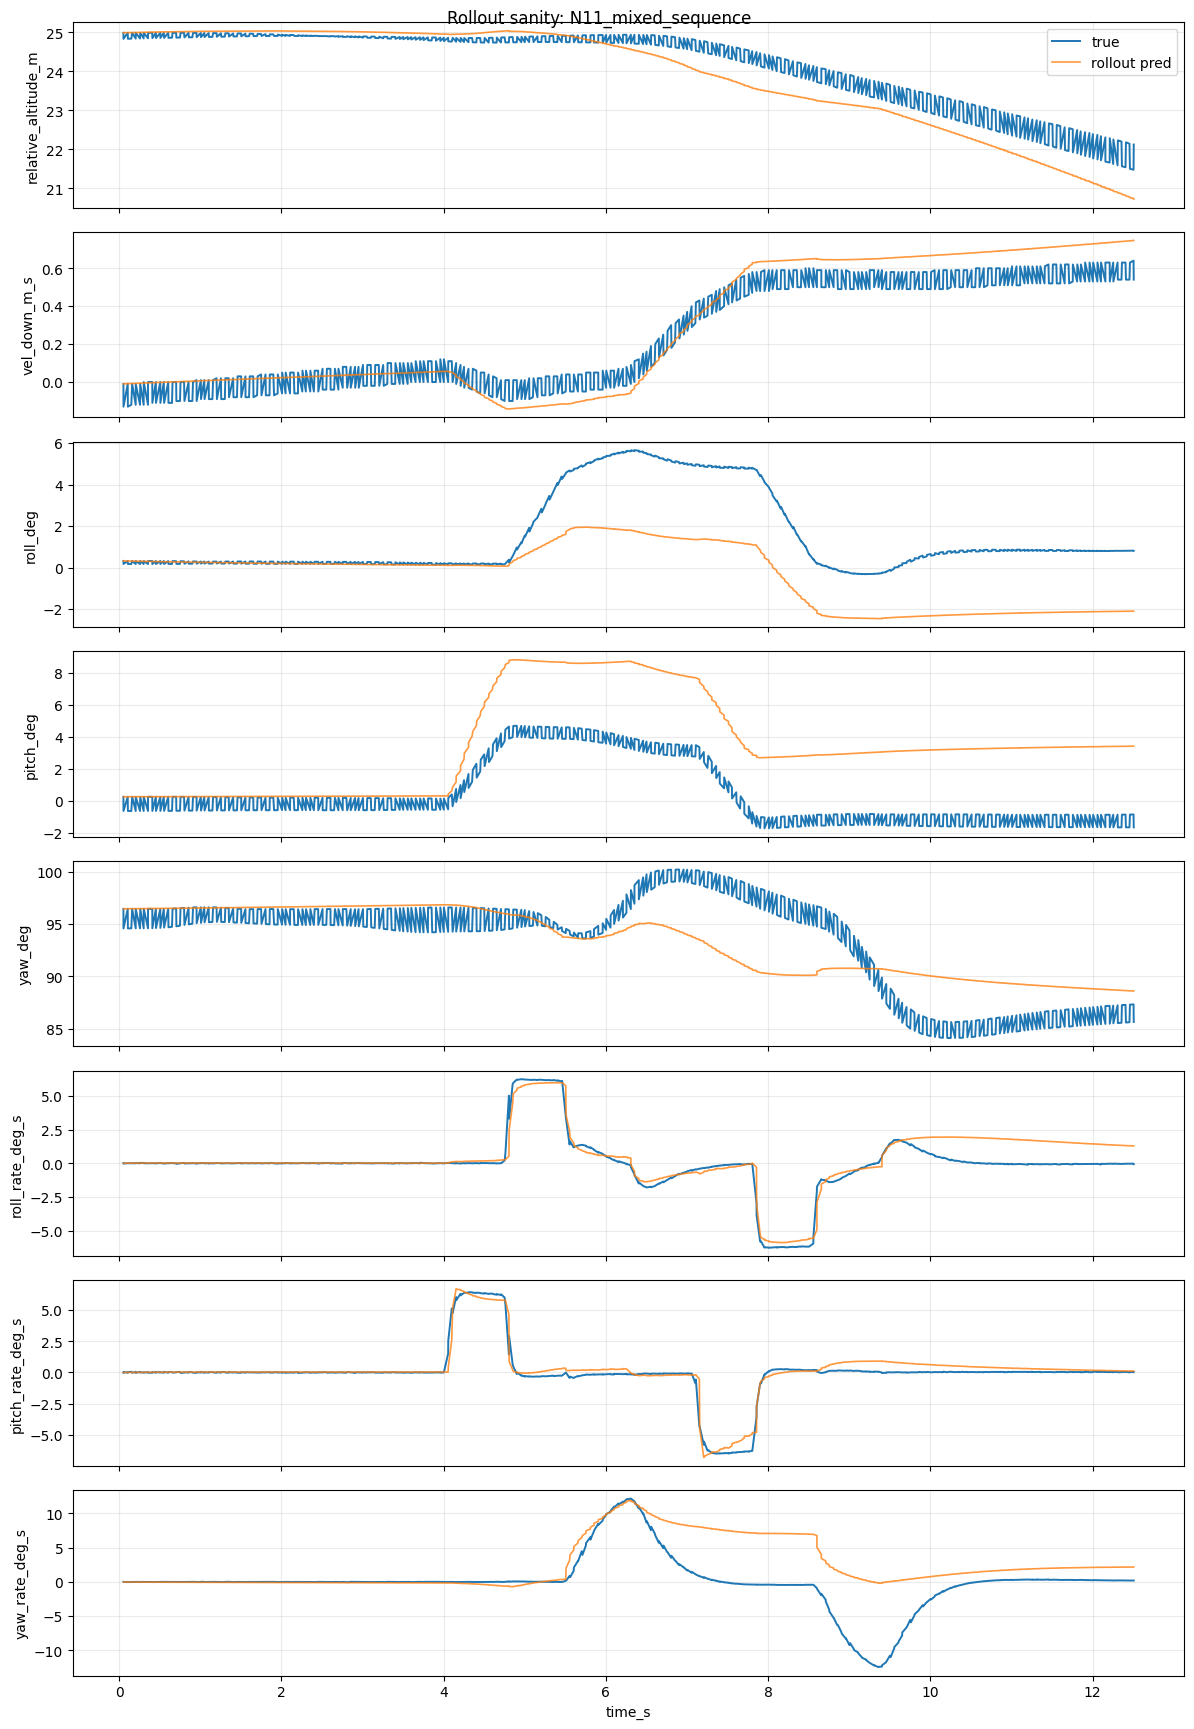

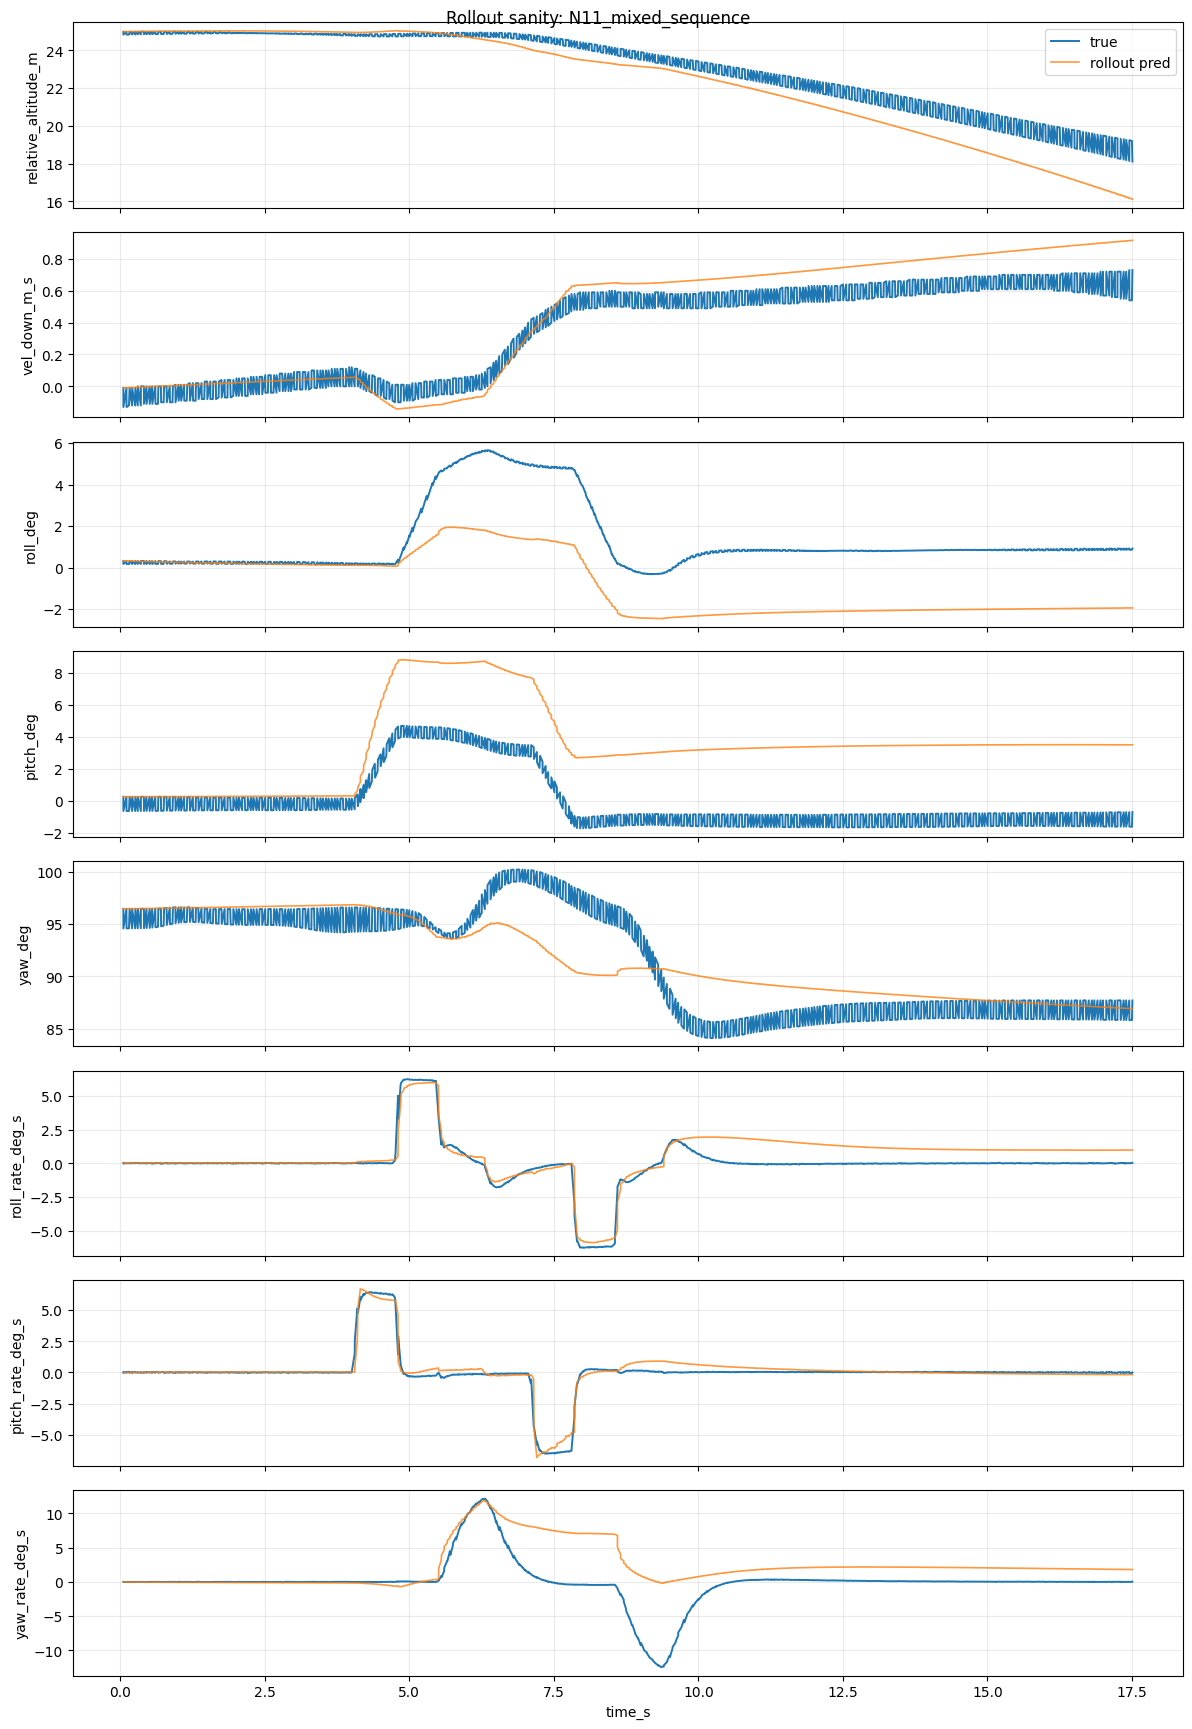

In [10]:
# Plot selected rollout scenarios
def plot_rollout(df, scenario, max_steps=500):
    result = rollout_scenario(df, scenario, max_steps=max_steps)
    if result is None:
        print('not enough rows for', scenario)
        return
    _, sdf, pred_states, true_next = result
    t = sdf['time_s'].to_numpy()
    plot_states = ['relative_altitude_m', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
    plot_states = [s for s in plot_states if s in state_cols]
    fig, axes = plt.subplots(len(plot_states), 1, figsize=(12, 2.2 * len(plot_states)), sharex=True)
    if len(plot_states) == 1:
        axes = [axes]
    for ax, state in zip(axes, plot_states):
        j = state_cols.index(state)
        y_true = true_next[:, j]
        y_pred = pred_states[:, j]
        if state.endswith('_rad_s'):
            y_true = np.rad2deg(y_true)
            y_pred = np.rad2deg(y_pred)
            label = state.replace('_rad_s', '_deg_s')
        else:
            label = state
        ax.plot(t, y_true, label='true', lw=1.4)
        ax.plot(t, y_pred, label='rollout pred', lw=1.2, alpha=0.8)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.25)
    axes[0].legend(loc='best')
    axes[-1].set_xlabel('time_s')
    fig.suptitle(f'Rollout sanity: {scenario}')
    plt.tight_layout()
    plt.show()

for scenario in sorted(test_df['scenario'].unique())[:3]:
    plot_rollout(test_df, scenario, max_steps=500)
if 'N11_mixed_sequence' in set(test_df['scenario']):
    plot_rollout(test_df, 'N11_mixed_sequence', max_steps=700)


In [11]:
# Save checkpoint for future MPC experiments
SAVE_ROOT = Path('/content/drive/MyDrive/PX4_Phase1_Models') if IN_COLAB else DATASET_PATH / 'models'
SAVE_ROOT.mkdir(parents=True, exist_ok=True)
stamp = time.strftime('%Y%m%d_%H%M%S')
ckpt_path = SAVE_ROOT / f'px4_phase1_rate_dynamics_mlp_v7_aux_accel_{stamp}.pt'

checkpoint = {
    'model_version': 'px4_phase1_rate_dynamics_mlp_v7_aux_accel',
    'state_dict': model.state_dict(),
    'model_config': {'n_in': len(feature_cols), 'n_out': len(target_cols), 'n_aux': len(aux_cols), **MODEL_CONFIG},
    'loss_config': {
        'data_weight': DATA_WEIGHT,
        'aux_data_weight': AUX_DATA_WEIGHT,
        'aux_consistency_weight': AUX_CONSISTENCY_WEIGHT,
        'alt_kin_weight': ALT_KIN_WEIGHT,
        'euler_kin_weight': EULER_KIN_WEIGHT,
        'target_data_weights': TARGET_DATA_WEIGHTS,
        'aux_data_weights': AUX_DATA_WEIGHTS,
        'alt_resid_scale_m': ALT_RESID_SCALE_M,
        'euler_resid_scale_rad': float(EULER_RESID_SCALE_RAD),
        'validation_policy': 'nominal_pool_random_validation_with_N11_mixed_test',
    },
    'feature_cols': feature_cols,
    'target_cols': target_cols,
    'aux_cols': aux_cols,
    'state_cols': state_cols,
    'action_cols': action_cols,
    'x_scaler': x_scaler.to_dict(feature_cols),
    'y_scaler': y_scaler.to_dict(target_cols),
    'aux_scaler': a_scaler.to_dict(aux_cols),
    'dataset_path': str(DATASET_PATH),
    'metadata': metadata,
    'history': hist_df.to_dict(orient='records'),
    'one_step_metrics': metrics_df.to_dict(orient='records'),
    'aux_metrics': aux_metrics_df.to_dict(orient='records'),
    'rollout_metrics': rollout_metrics_df.to_dict(orient='records'),
}
torch.save(checkpoint, ckpt_path)
print('saved:', ckpt_path)


saved: /content/drive/MyDrive/PX4_Phase1_Models/px4_phase1_rate_dynamics_mlp_v7_aux_accel_20260508_084438.pt


In [12]:
# Minimal load check
loaded = torch.load(ckpt_path, map_location='cpu')
print('loaded keys:', sorted(loaded.keys()))
print('feature count:', len(loaded['feature_cols']))
print('target count:', len(loaded['target_cols']))
print('aux count:', len(loaded['aux_cols']))


loaded keys: ['action_cols', 'aux_cols', 'aux_metrics', 'aux_scaler', 'dataset_path', 'feature_cols', 'history', 'loss_config', 'metadata', 'model_config', 'model_version', 'one_step_metrics', 'rollout_metrics', 'state_cols', 'state_dict', 'target_cols', 'x_scaler', 'y_scaler']
feature count: 23
target count: 10
aux count: 6
